<a href="https://colab.research.google.com/github/sam02/tp547/blob/main/codigos/codigos_aula11/linecodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\eduar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\eduar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


[0 1 0 ... 1 0 1]


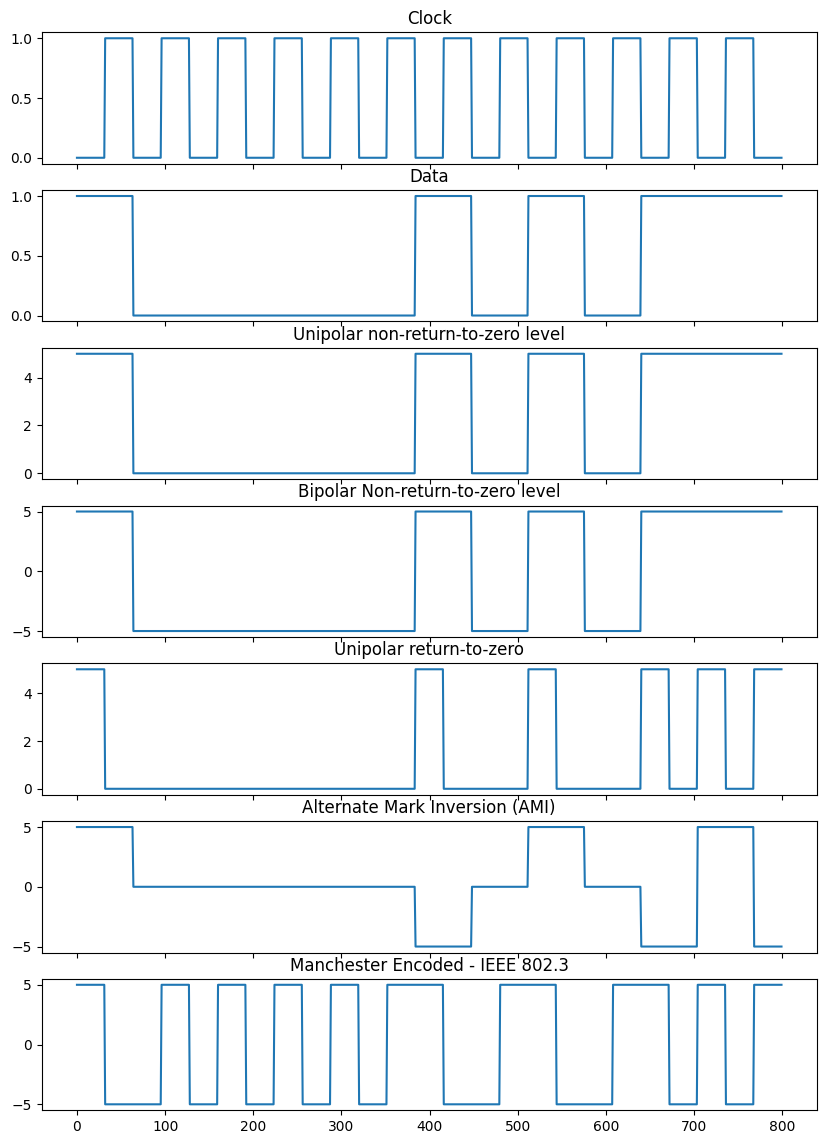

In [2]:
# -*- coding: utf-8 -*-


import numpy as np
import matplotlib.pyplot as plt

L = 32 # number of digital samples per data bit
Fs = 8*L # Sampling frequency
voltageLevel = 5 # peak voltage level in Volts
data = (np.random.rand(10000)>0.5).astype(int) # random 1s and 0s for data
clk = np.arange(0,2*len(data)) % 2 # clock samples
print(clk)
"""**AMI encoding**"""

ami = 1*data; previousOne = 0

for ii in range(0,len(data)):
  if (ami[ii]==1) and (previousOne==0):
    ami[ii] = voltageLevel
    previousOne=1;
  if (ami[ii]==1) and (previousOne==1):
    ami[ii]= -voltageLevel
    previousOne = 0;

"""**Converting the bits to sequences and mapping to voltage levels**"""

clk_sequence = np.repeat(clk,L)
data_sequence = np.repeat(data,2*L)
unipolar_nrz_l = voltageLevel*data_sequence
nrz_encoded = voltageLevel*(2*data_sequence - 1)
unipolar_rz = voltageLevel * (data_sequence * (1 - clk_sequence))
ami_sequence = np.repeat(ami,2*L)
manchester_encoded = voltageLevel* (2*np.logical_xor(data_sequence,clk_sequence).astype(int)-1)

fig, ax = plt.subplots(7,1,sharex='col', figsize=(10, 14))
ax[0].plot(clk_sequence[0:800]);ax[0].set_title('Clock')
ax[1].plot(data_sequence[0:800]);ax[1].set_title('Data')
ax[2].plot(unipolar_nrz_l[0:800]); ax[2].set_title('Unipolar non-return-to-zero level')
ax[3].plot(nrz_encoded[0:800]); ax[3].set_title('Bipolar Non-return-to-zero level')
ax[4].plot(unipolar_rz[0:800]); ax[4].set_title('Unipolar return-to-zero')
ax[5].plot(ami_sequence[0:800]); ax[5].set_title('Alternate Mark Inversion (AMI)')
ax[6].plot(manchester_encoded[0:800]); ax[6].set_title('Manchester Encoded - IEEE 802.3')
plt.show()

